# Quick Start of BandHiC

In [1]:
import bandhic as bh
import numpy as np
from matplotlib import pyplot as plt

## Load .npz file from local disk

In [2]:
mat = bh.load_npz('../data/sample.npz')
print(mat)

band_hic_matrix(shape=(6134, 6134), diag_num=200, dtype=float64)


In [3]:
mat.data, mat.data.shape

(array([[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [762., 229.,  10., ...,   0.,   0.,   0.],
        [435., 111.,   0., ...,   0.,   0.,   0.],
        [ 26.,   0.,   0., ...,   0.,   0.,   0.]]),
 (6134, 200))

In [4]:
print(mat.shape)
print(mat.bin_num)
print(mat.diag_num)
print(mat.dtype)
print(mat.default_value)

(6134, 6134)
6134
200
float64
0


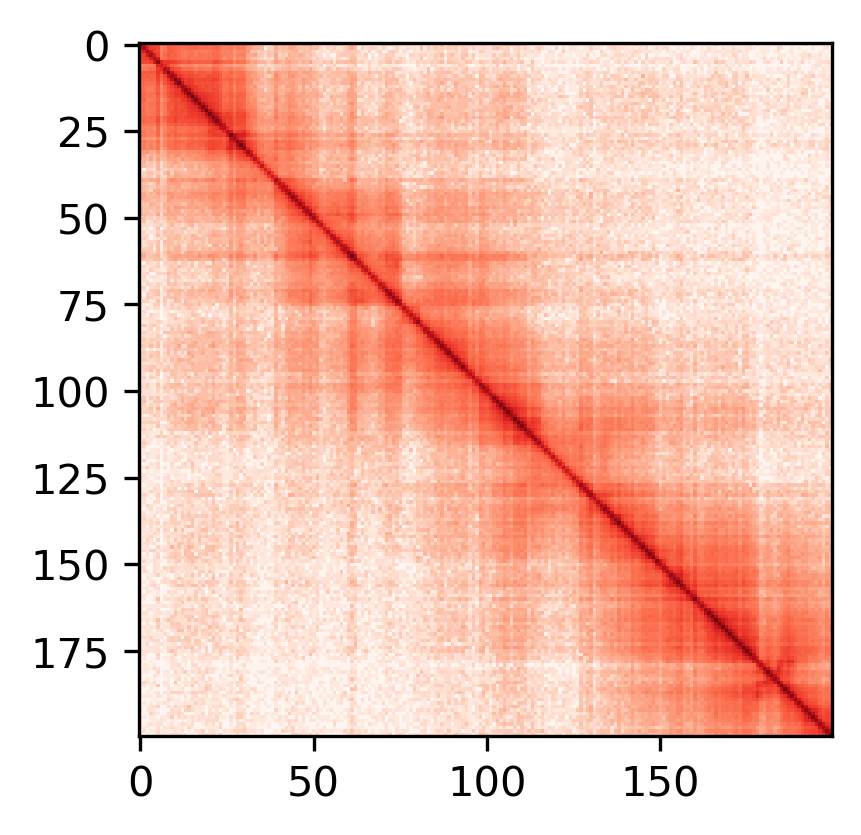

In [5]:
plt.figure(figsize=(3, 3),dpi=300)
plt.imshow(np.log(mat[400:600].todense() + 1), cmap='Reds')
plt.show()

## Indexing

Single-element access (scalar)

In [6]:
mat[1, 2]

0.0

Square submatrix via two-slice indexing returns `band_hic_matrix`

In [7]:
mat[1:3, 1:3]

band_hic_matrix(shape=(2, 2), diag_num=2, dtype=float64)

In [8]:
mat[1:3, 1:3].todense()

array([[0., 0.],
       [0., 0.]])

Single-axis slice returns `band_hic_matrix` for square region

In [9]:
mat[0:2]  # equivalent to mat[0:2, 0:2]

band_hic_matrix(shape=(2, 2), diag_num=2, dtype=float64)

Fancy indexing returns `ndarray` or `MaskedArray`

In [10]:
mat[[0,2,0], [1,2,3]]

array([0., 0., 0.])

Boolean indexing with `band_hic_matrix`

In [11]:
mat[mat > 0]  # Use boolean mask for indexing

array([  2.,   8.,  11., ..., 435., 111.,  26.])

## Masking 

Add row/column mask:

In [12]:
mask = mat.sum(axis=1) == 0
mat.add_mask_row_col(mask)
mat.mask_row_col

array([ True,  True,  True, ..., False, False, False])

Add item-wise mask:

In [13]:
mat.add_mask([0, 1], [1, 2])

In [14]:
mat[[0, 1], [1, 2]]

masked_array(data=[--, --],
             mask=[ True,  True],
       fill_value=0.0,
            dtype=float64)

Remove mask for specified indices

In [15]:
mat.unmask(( [0],[1] ))

In [16]:
mat.mask

array([[ True, False,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [False, False, False, ...,  True,  True,  True],
       [False, False,  True, ...,  True,  True,  True],
       [False,  True,  True, ...,  True,  True,  True]])

In [17]:
mat.mask_row_col

array([False, False,  True, ..., False, False, False])

Drop all item-wise mask but preserve all row/column mask.

In [18]:
mat.drop_mask()

Drop all row/column mask.

In [19]:
mat.drop_mask_row_col()

Remove all item-wise mask and row/column mask.

In [20]:
mat.unmask()
print(mat.mask)
print(mat.mask_row_col)

None
None


Remove all item-wise mask and row/column mask.

In [21]:
mat.clear_mask()
print(mat.mask)
print(mat.mask_row_col)

None
None


## Universal functions(`ufunc`)

Universal functions that BandHiC support:
| Function        | Description                      | Function         | Description                       |
|------------------|-----------------------------------|------------------|-----------------------------------|
| `absolute`       | Absolute value                    | `add`            | Element-wise addition             |
| `arccos`         | Inverse cosine                    | `arccosh`        | Inverse hyperbolic cosine         |
| `arcsin`         | Inverse sine                      | `arcsinh`        | Inverse hyperbolic sine           |
| `arctan`         | Inverse tangent                   | `arctan2`        | Arctangent of y/x with quadrant   |
| `arctanh`        | Inverse hyperbolic tangent        | `bitwise_and`    | Element-wise bitwise AND          |
| `bitwise_or`     | Element-wise bitwise OR           | `bitwise_xor`    | Element-wise bitwise XOR          |
| `cbrt`           | Cube root                         | `conj`           | Complex conjugate                 |
| `conjugate`      | Alias for `conj`                  | `cos`            | Cosine function                   |
| `cosh`           | Hyperbolic cosine                 | `deg2rad`        | Degrees to radians                |
| `degrees`        | Radians to degrees                | `divide`         | Element-wise division             |
| `divmod`         | Quotient and remainder            | `equal`          | Element-wise equality test        |
| `exp`            | Exponential                       | `exp2`           | Base-2 exponential                |
| `expm1`          | `exp(x) - 1`                      | `fabs`           | Absolute value (float)            |
| `float_power`    | Floating-point power              | `floor_divide`   | Integer division (floor)          |
| `fmod`           | Modulo operation                  | `gcd`            | Greatest common divisor           |
| `greater`        | Element-wise greater-than test    | `greater_equal`  | Greater-than or equal test        |
| `heaviside`      | Heaviside step function           | `hypot`          | Euclidean norm                    |
| `invert`         | Bitwise inversion                 | `lcm`            | Least common multiple             |
| `left_shift`     | Bitwise left shift                | `less`           | Element-wise less-than test       |
| `less_equal`     | Less-than or equal test           | `log`            | Natural logarithm                 |
| `log1p`          | `log(1 + x)`                      | `log2`           | Base-2 logarithm                  |
| `log10`          | Base-10 logarithm                 | `logaddexp`      | `log(exp(x) + exp(y))`            |
| `logaddexp2`     | Base-2 version of logaddexp       | `logical_and`    | Element-wise logical AND          |
| `logical_or`     | Element-wise logical OR           | `logical_xor`    | Element-wise logical XOR          |
| `maximum`        | Element-wise maximum              | `minimum`        | Element-wise minimum              |
| `mod`            | Remainder (modulo)                | `multiply`       | Element-wise multiplication       |
| `negative`       | Element-wise negation             | `not_equal`      | Element-wise inequality test      |
| `positive`       | Returns input unchanged           | `power`          | Raise to power                    |
| `rad2deg`        | Radians to degrees                | `radians`        | Degrees to radians                |
| `reciprocal`     | Element-wise reciprocal           | `remainder`      | Modulo remainder                  |
| `right_shift`    | Bitwise right shift               | `rint`           | Round to nearest integer          |
| `sign`           | Sign of input                     | `sin`            | Sine function                     |
| `sinh`           | Hyperbolic sine                   | `sqrt`           | Square root                       |
| `square`         | Square of input                   | `subtract`       | Element-wise subtraction          |
| `tan`            | Tangent function                  | `tanh`           | Hyperbolic tangent                |
| `true_divide`    | Division that returns float       |                  |                                   |


BandHiC supports these universal functions, and they can be used in the following four ways:

### 1. As methods of the `band_hic_matrix` object:

When two band_hic_matrix objects are involved, their shape and diag_num must match

In [22]:
mat1 = mat.copy()
mat2 = mat.copy()
mat3 = mat1.add(mat2)
mat4 = mat1.less(mat2)
mat5 = mat1.negative()

### 2. As functions of the **BandHiC** package

In [23]:
mat3 = bh.add(mat1, mat2)
mat4 = bh.less(mat1, mat2)
mat5 = bh.negative(mat1)

### 3. Using mathematical operators:

In [24]:
mat3 = mat1 + mat2
mat4 = mat1 < mat2
mat5 = - mat1

### 4. Calling NumPy's universal functions:

In [25]:
mat3 = np.add(mat1, mat2)
mat4 = np.less(mat1, mat2)
mat5 = np.negative(mat1)

## Array reduction and other Functions


| Function | Description |
|----------|-------------|
| `sum`    | Compute the sum of all elements along the specified axis |
| `prod`   | Compute the product of all elements along the specified axis |
| `min`    | Return the minimum value along the specified axis |
| `max`    | Return the maximum value along the specified axis |
| `mean`   | Compute the arithmetic mean along the specified axis |
| `var`    | Compute the variance (average squared deviation) |
| `std`    | Compute the standard deviation (square root of variance) |
| `ptp`    | Compute the range (max - min) of values along the axis |
| `all`    | Return `True` if all elements evaluate to `True` |
| `any`    | Return `True` if any element evaluates to `True` |
| `clip`   | Limit values to a specified min and max range |

BandHiC supports these functions, and they can be used in the following three ways:

### 1. As methods of the `band_hic_matrix` object:


Compute the sum of all elements including out-of-band values filled with `default_value`.

In [26]:
result0 = mat1.sum()

Compute the sum of all elements along the `row` axis

In [27]:
result1 = mat1.sum(axis=0)
result1 = mat1.sum(axis='row')

In [28]:
result1

array([   0.,    0.,    0., ..., 1923., 1356.,  207.])

Compute the sum of all elements along the `diag` axis

In [29]:
mat_sum = mat1.sum(axis='diag')

### 2. Calling **BandHiC**'s functions:

In [30]:
result0 = bh.sum(mat1)
result1 = bh.sum(mat1, axis=0)
result2 = bh.sum(mat1, axis='diag')

### 3. Calling NumPy's functions:

In [31]:
result0 = np.sum(mat1)
result1 = np.sum(mat1, axis=0)
result2 = np.sum(mat1, axis='diag')

## TAD calling with TopDom

In [32]:
mat.clear_mask()
domains, bins = bh.call_tad(mat, 10_000, chrom_short='20')

/Users/wwb/Documents/workspace/BandHiC-Master/bandhic/bandhic.py:671: UserWarning: Column indices should not be less than row indices; invalid indices are swapped.
  warnings.warn(


In [33]:
domains

,chr,from.id,from.coord,to.id,to.coord,tag
0,chr20,0,0,307,3070000,gap
307,chr20,307,3070000,353,3530000,domain
353,chr20,353,3530000,373,3730000,domain
373,chr20,373,3730000,394,3940000,domain
394,chr20,394,3940000,398,3980000,domain
...,...,...,...,...,...,...
6113,chr20,6113,61130000,6117,61170000,domain
6117,chr20,6117,61170000,6124,61240000,domain
6124,chr20,6124,61240000,6127,61270000,domain
6127,chr20,6127,61270000,6129,61290000,domain


In [34]:
bins

,id,chr,from.coord,to.coord,local.ext,mean.cf,pvalue
0,0,chr20,0,10000,-0.5,0.000,1.0
1,1,chr20,10000,20000,-0.5,0.000,1.0
2,2,chr20,20000,30000,-0.5,0.000,1.0
3,3,chr20,30000,40000,-0.5,0.000,1.0
4,4,chr20,40000,50000,-0.5,0.000,1.0
...,...,...,...,...,...,...,...
6129,6129,chr20,61290000,61300000,0.0,15.025,1.0
6130,6130,chr20,61300000,61310000,1.0,17.050,1.0
6131,6131,chr20,61310000,61320000,0.0,15.450,1.0
6132,6132,chr20,61320000,61330000,0.0,7.850,1.0
